In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
#%matplotlib notebook
#%autosave 0
    
import logging
logging.basicConfig(format='%(asctime)s %(levelname)s:%(message)s', level=logging.INFO, datefmt='%I:%M:%S')

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sdata.parameter import Parameter, Distribution

In [ ]:
def swift()
self._linear_part * self._epsilon +
                parameters[0] * (self._epsilon + parameters[1]) ** parameters[2]

In [27]:
param_constant = Parameter(name="constant_param", value=10.0, 
                           description="This is a constant parameter.")
param_constant

(constant_param|10.0|[None]|Constant)

In [19]:
param_discrete = Parameter(
    name="discrete_param",
    value="a",
    range=["a", "b", "c", "d", "e", "f"]
)
param_discrete

(discrete_param|a|[['a', 'b', 'c', 'd', '...']]|DiscreteVariable)

In [25]:
param_variable = Parameter(name="variable_param", value=5.0, range=(0.0, 10.0), 
                           description="This is a variable parameter.")
param_variable

(variable_param|5.0|[0,10]|Variable)

In [26]:
param_discrete = Parameter(name="discrete_param", value="a", range=["a", "b", "c"], 
                           description="This is a discrete parameter.")
param_discrete

(discrete_param|a|[['a', 'b', 'c']]|DiscreteVariable)

In [75]:
import numpy as np
from scipy.optimize import fsolve
from typing import Dict

def fkt(x, a, m):
    y = a * np.log((m / a) * x + 1)
    return y
    
def find_a(params: Dict[str, Parameter]) -> float:
    """
    Berechnet den Parameter 'a', der die gegebene Gleichung erfüllt.

    :param params: Dictionary mit den Parametern 'm', 'x_1', und 'y_1' als Parameter-Objekte.
        - 'm': Parameter-Objekt für die Steigung bei x = 0.
        - 'x_1': Parameter-Objekt für den Punkt x_1.
        - 'y_1': Parameter-Objekt für den Wert y_1 an der Stelle x_1.
    :return: Der berechnete Wert von 'a'.
    """
    # Extrahieren der Parameterwerte
    m = params['m'].value
    x_1 = params['x_1'].value
    y_1 = params['y_1'].value

    # Funktion, die die Gleichung darstellt
    def equation_for_a(a):
        return a * np.log((m / a) * x_1 + 1) - y_1

    # Erste Schätzung für a
    initial_guess = params['a'].value

    # Numerische Lösung für a
    a_solution = fsolve(equation_for_a, initial_guess)[0]
    params['a'].value = a_solution
    return params

# Beispielaufruf
params = {
    'a': Parameter(name='a', value=2, range=(0, 10), description='Faktor a'),
    'm': Parameter(name='m', value=30, range=(0, 100), description='Steigung bei x = 0'),
    'x_1': Parameter(name='x_1', value=2.0, range=(0, 5), description='Punkt x_1'),
    'y_1': Parameter(name='y_1', value=2.5, range=(0, 5), description='Wert y_1 an der Stelle x_1')
}

params = find_a(params)
a_solution = params['a'].value
find_a(params)
print(f"Berechnetes a: {a_solution:.4f}")
params

Berechnetes a: 0.5270


{'a': (a|0.5270265078392228|[0,10]|Variable),
 'm': (m|30|[0,1e+02]|Variable),
 'x_1': (x_1|2.0|[0,5]|Variable),
 'y_1': (y_1|2.5|[0,5]|Variable)}

In [76]:
df = pd.DataFrame({"x":np.linspace(0,5,100)})
m = params['m'].value
a = params['a'].value
df["y"] = fkt(df.x, a, m)
df.head()

,x,y
0,0.000000,0.000000
1,0.050505,0.713869
2,0.101010,1.006365
3,0.151515,1.193364
4,0.202020,1.331110


(2.0, 2.5)

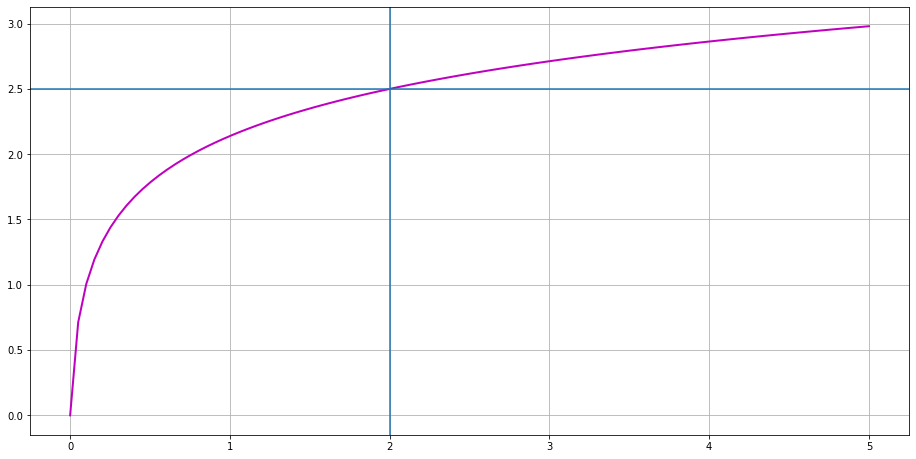

In [77]:
B = 400/25.4
H = 200/25.4
fig, ax = plt.subplots(1,1, figsize=(B, H))
ax.plot(df.x, df.y, lw=2, c="m")
ax.axhline(params['y_1'].value)
ax.axvline(params['x_1'].value)
ax.grid(True)
params['x_1'].value, params['y_1'].value

In [78]:
params['m'].to_dict()

{'name': 'm',
 'value': 30,
 'range': (0, 100),
 'type': 'Variable',
 'description': 'Steigung bei x = 0',
 'discrete_values': None,
 'distribution': {'name': 'uniform', 'params': {}}}

In [79]:
params['a'].to_dict()

{'name': 'a',
 'value': 0.5270265078392228,
 'range': (0, 10),
 'type': 'Variable',
 'description': 'Faktor a',
 'discrete_values': None,
 'distribution': {'name': 'uniform', 'params': {}}}

In [69]:
   
# Beispiel: Parameter erstellen und als JSON speichern
param_constant = Parameter(name="constant_param", value=10.0)
print(param_constant.to_json())

param_variable = Parameter(name="variable_param", value=5.0, range=(0.0, 10.0))
print(param_variable.to_json())

param_distributed = Parameter(
    name="distributed_param",
    value=5.0,
    range=(0.0, 10.0),
    distribution=Distribution("truncated_gauss", mean=5.0, std_dev=1.0)
)
print(param_distributed.to_json())

param_discrete = Parameter(
    name="discrete_param",
    value="a",
    range=["a", "b", "c"]
)
print(param_discrete.to_json())

# Sampling von mehreren Werten
sampled_values = param_distributed.sample_values(10)
print(f"Sampled values: {sampled_values}")

sampled_discrete_values = param_discrete.sample_values(10)
print(f"Sampled discrete values: {sampled_discrete_values}")

# Typänderung
param_distributed.set_type("Constant")
print(param_distributed.to_json())

# Sampling nach Typänderung
sampled_values_constant = param_distributed.sample_values(10)
print(f"Sampled values after type change: {sampled_values_constant}")

# JSON-Import
loaded_param = Parameter.from_json(param_distributed.to_json())
print(loaded_param.to_dict())

{
    "name": "constant_param",
    "value": 10.0,
    "range": null,
    "type": "Constant",
    "description": null,
    "discrete_values": null,
    "distribution": null
}
{
    "name": "variable_param",
    "value": 5.0,
    "range": [
        0.0,
        10.0
    ],
    "type": "Variable",
    "description": null,
    "discrete_values": null,
    "distribution": {
        "name": "uniform",
        "params": {}
    }
}
{
    "name": "distributed_param",
    "value": 5.0,
    "range": [
        0.0,
        10.0
    ],
    "type": "Variable",
    "description": null,
    "discrete_values": null,
    "distribution": {
        "name": "truncated_gauss",
        "params": {
            "mean": 5.0,
            "std_dev": 1.0
        }
    }
}
{
    "name": "discrete_param",
    "value": "a",
    "range": null,
    "type": "DiscreteVariable",
    "description": null,
    "discrete_values": [
        "a",
        "b",
        "c"
    ],
    "distribution": null
}
Sampled values: [5.751

In [5]:
c = Parameter(name="c", value=5.0, range=(0.01, 10.00))
c.type = "Constant"
c

(c|5.0|[0.01,10]|Constant)

In [6]:
    
# Beispiel: Parameter erstellen und als JSON speichern
param_constant = Parameter(name="constant_param", value=10.0)
print(param_constant.to_json())

param_variable = Parameter(name="variable_param", value=5.0, range=(0.0, 10.0))
print(param_variable.to_json())

param_distributed = Parameter(
    name="distributed_param",
    value=5.0,
    range=(0.0, 10.0),
    distribution=Distribution("truncated_gauss", mean=5.0, std_dev=1.0)
)
print(param_distributed.to_json())

# Sampling von mehreren Werten
sampled_values = param_distributed.sample_values(10)
print(f"Sampled values: {sampled_values}")

# Typänderung
param_distributed.set_type("Constant")
print(param_distributed.to_json())

# Sampling nach Typänderung
sampled_values_constant = param_distributed.sample_values(10)
print(f"Sampled values after type change: {sampled_values_constant}")

# JSON-Import
loaded_param = Parameter.from_json(param_distributed.to_json())
print(loaded_param.to_dict())

{
    "name": "constant_param",
    "value": 10.0,
    "range": null,
    "type": "Constant",
    "description": null,
    "discrete_values": null,
    "distribution": null
}
{
    "name": "variable_param",
    "value": 5.0,
    "range": [
        0.0,
        10.0
    ],
    "type": "Variable",
    "description": null,
    "discrete_values": null,
    "distribution": {
        "name": "uniform",
        "params": {}
    }
}
{
    "name": "distributed_param",
    "value": 5.0,
    "range": [
        0.0,
        10.0
    ],
    "type": "Variable",
    "description": null,
    "discrete_values": null,
    "distribution": {
        "name": "truncated_gauss",
        "params": {
            "mean": 5.0,
            "std_dev": 1.0
        }
    }
}
Sampled values: [6.832838271945656, 5.495607784535505, 5.2472582640667556, 6.181108383081606, 5.670299991279602, 5.808760485741727, 5.362602554254639, 4.580362340935182, 4.453874380621541, 6.835529058563544]
{
    "name": "distributed_param",
  

In [7]:
param_constant.sample_values(10)

[10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0]

In [8]:
param_variable.sample_values(10)

[8.465405629064586,
 1.7805072236850383,
 2.2996517566144634,
 0.9684514835012203,
 9.980556673797356,
 8.610272997505406,
 1.1401093056954437,
 8.329197339623132,
 6.681019212133067,
 2.683196621135372]

In [9]:
param_distributed.sample_values(10)

[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0]

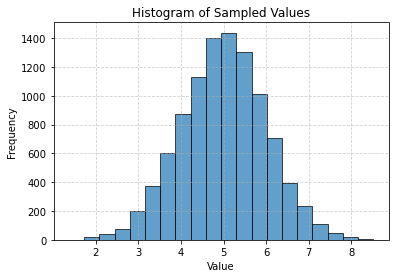

In [10]:
param_distributed = Parameter(
    name="distributed_param",
    value=5.0,
    range=(0.0, 10.0),
    distribution=Distribution("truncated_gauss", mean=5.0, std_dev=1.0)
)
sampled_values = param_distributed.sample_values(10000)
plt.hist(sampled_values, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of Sampled Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)


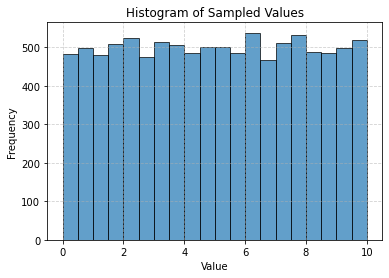

In [11]:
param_distributed = Parameter(
    name="distributed_param",
    value=5.0,
    range=(0.0, 10.0),
    distribution=Distribution("uniform")
)
sampled_values = param_distributed.sample_values(10000)
plt.hist(sampled_values, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of Sampled Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)


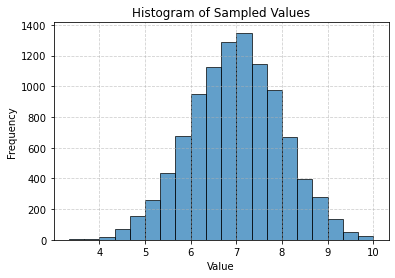

In [12]:

# Plot als Histogramm
param_distributed = Parameter(
    name="distributed_param",
    value=5.0,
    range=(0.0, 10.0),
    distribution=Distribution("truncated_gauss", mean=7.0, std_dev=1.0)
)
#param_distributed.type = "Constant"
sampled_values = param_distributed.sample_values(10000)
plt.hist(sampled_values, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of Sampled Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)

(2.0, 10.0)


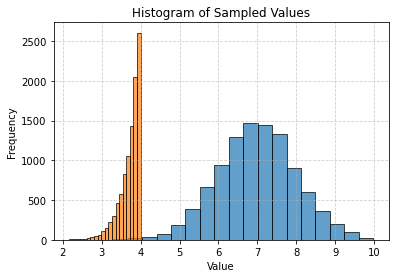

In [13]:

# Plot als Histogramm
param_distributed = Parameter(
    name="distributed_param",
    value=5.0,
    range=(2.0, 10.0),
    distribution=Distribution("truncated_gauss", mean=7.0, std_dev=1.0)
)
#param_distributed.type = "Constant"
sampled_values = param_distributed.sample_values(10000)
print(param_distributed.range)
param_distributed.range = (2,4)
sampled_values2 = param_distributed.sample_values(10000)

plt.hist(sampled_values, bins=20, edgecolor='black', alpha=0.7)
plt.hist(sampled_values2, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of Sampled Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)

In [14]:
param_distributed = Parameter(
    name="distributed_param",
    value=5.0,
    range=(2.0, 10.0),
    distribution=Distribution("truncated_gauss", mean=7.0, std_dev=1.0)
)
j = param_distributed.to_json()
j

'{\n    "name": "distributed_param",\n    "value": 5.0,\n    "range": [\n        2.0,\n        10.0\n    ],\n    "type": "Variable",\n    "description": null,\n    "discrete_values": null,\n    "distribution": {\n        "name": "truncated_gauss",\n        "params": {\n            "mean": 7.0,\n            "std_dev": 1.0\n        }\n    }\n}'

In [15]:
p = Parameter.from_json(j)
p

(distributed_param|5.0|[None]|Variable)

(2.0, 10.0)


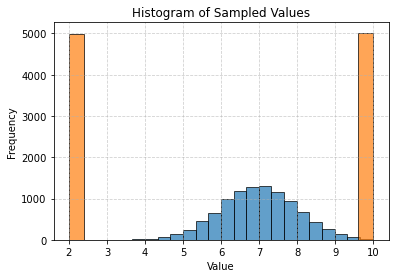

In [16]:
sampled_values = param_distributed.sample_values(10000)
sampled_values2 = p.sample_values(10000)
print(param_distributed.range)
plt.hist(sampled_values, bins=20, edgecolor='black', alpha=0.7)
plt.hist(sampled_values2, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of Sampled Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)

In [17]:
p = Parameter(
    name="a",
    value=5.0,
    range=(2.0, 10.0),
    #distribution=Distribution("truncated_gauss", mean=7.0, std_dev=1.0)
)
p

(a|5.0|[2,10]|Variable)

(2.0, 10.0)


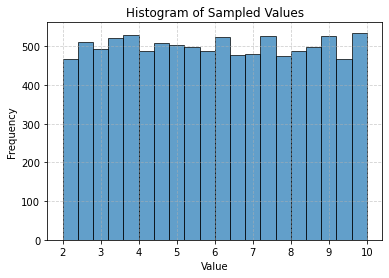

In [50]:
sampled_values = p.sample_values(10000)
print(param_distributed.range)
plt.hist(sampled_values, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of Sampled Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)